# Tutto in sklearn

R² Train: 0.924
R² Test: 0.441


<Figure size 1500x1000 with 0 Axes>

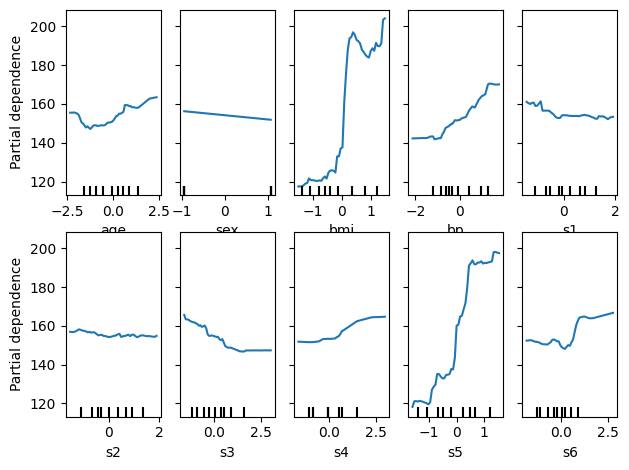

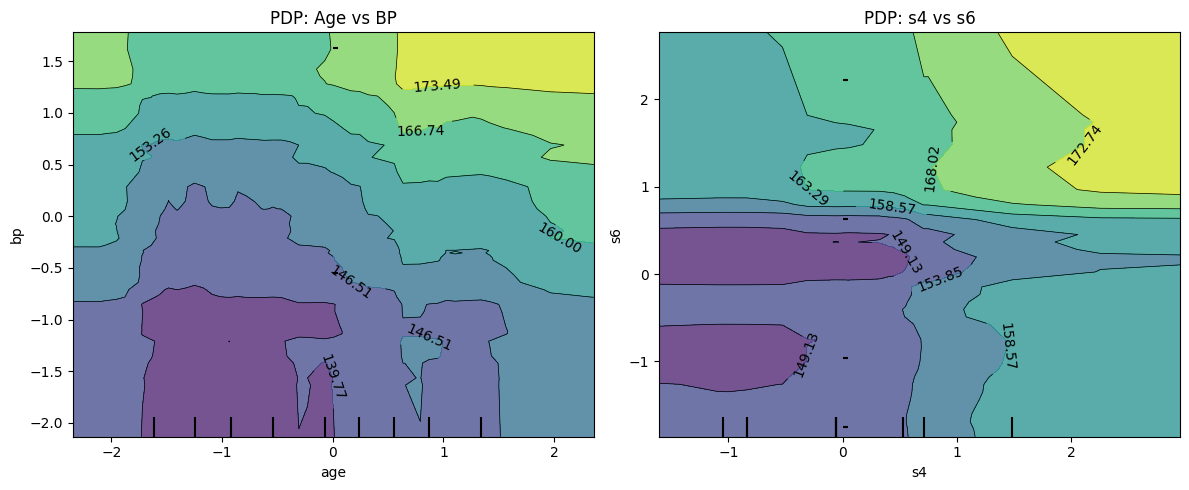

In [14]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Carica il dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names

# Split e standardizzazione
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Addestra Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Valuta il modello
train_score = rf.score(X_train_scaled, y_train)
test_score = rf.score(X_test_scaled, y_test)
print(f"R² Train: {train_score:.3f}")
print(f"R² Test: {test_score:.3f}")

# PDP per singole feature
plt.figure(figsize=(15, 10))
display = PartialDependenceDisplay.from_estimator(
    estimator=rf,
    X=X_test_scaled,
    features=range(10),
    feature_names=feature_names,
    n_cols=5,
    grid_resolution=50,
    random_state=42
)
plt.tight_layout()
plt.show()

# PDP bidimensionali
age_idx = feature_names.index('age')
bp_idx = feature_names.index('bp')
s4_idx = feature_names.index('s4')
s6_idx = feature_names.index('s6')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# PDP per age e bp
display1 = PartialDependenceDisplay.from_estimator(
    estimator=rf,
    X=X_test_scaled,
    features=[(age_idx, bp_idx)],
    feature_names=feature_names,
    kind='average',
    random_state=42,
    ax=[ax1]
)
ax1.set_title('PDP: Age vs BP')

# PDP per s4 e s6
display2 = PartialDependenceDisplay.from_estimator(
    estimator=rf,
    X=X_test_scaled,
    features=[(s4_idx, s6_idx)],
    feature_names=feature_names,
    kind='average',
    random_state=42,
    ax=[ax2]
)
ax2.set_title('PDP: s4 vs s6')

plt.tight_layout()
plt.show()

# Pytorch + scratch

Epoch [10/100], Loss: 29658.0703
Epoch [20/100], Loss: 29566.3887
Epoch [30/100], Loss: 29450.6914
Epoch [40/100], Loss: 29289.8047
Epoch [50/100], Loss: 29064.8555
Epoch [60/100], Loss: 28753.6836
Epoch [70/100], Loss: 28331.1055
Epoch [80/100], Loss: 27769.8418
Epoch [90/100], Loss: 27042.6875
Epoch [100/100], Loss: 26127.2812

Test Loss: 23179.2324


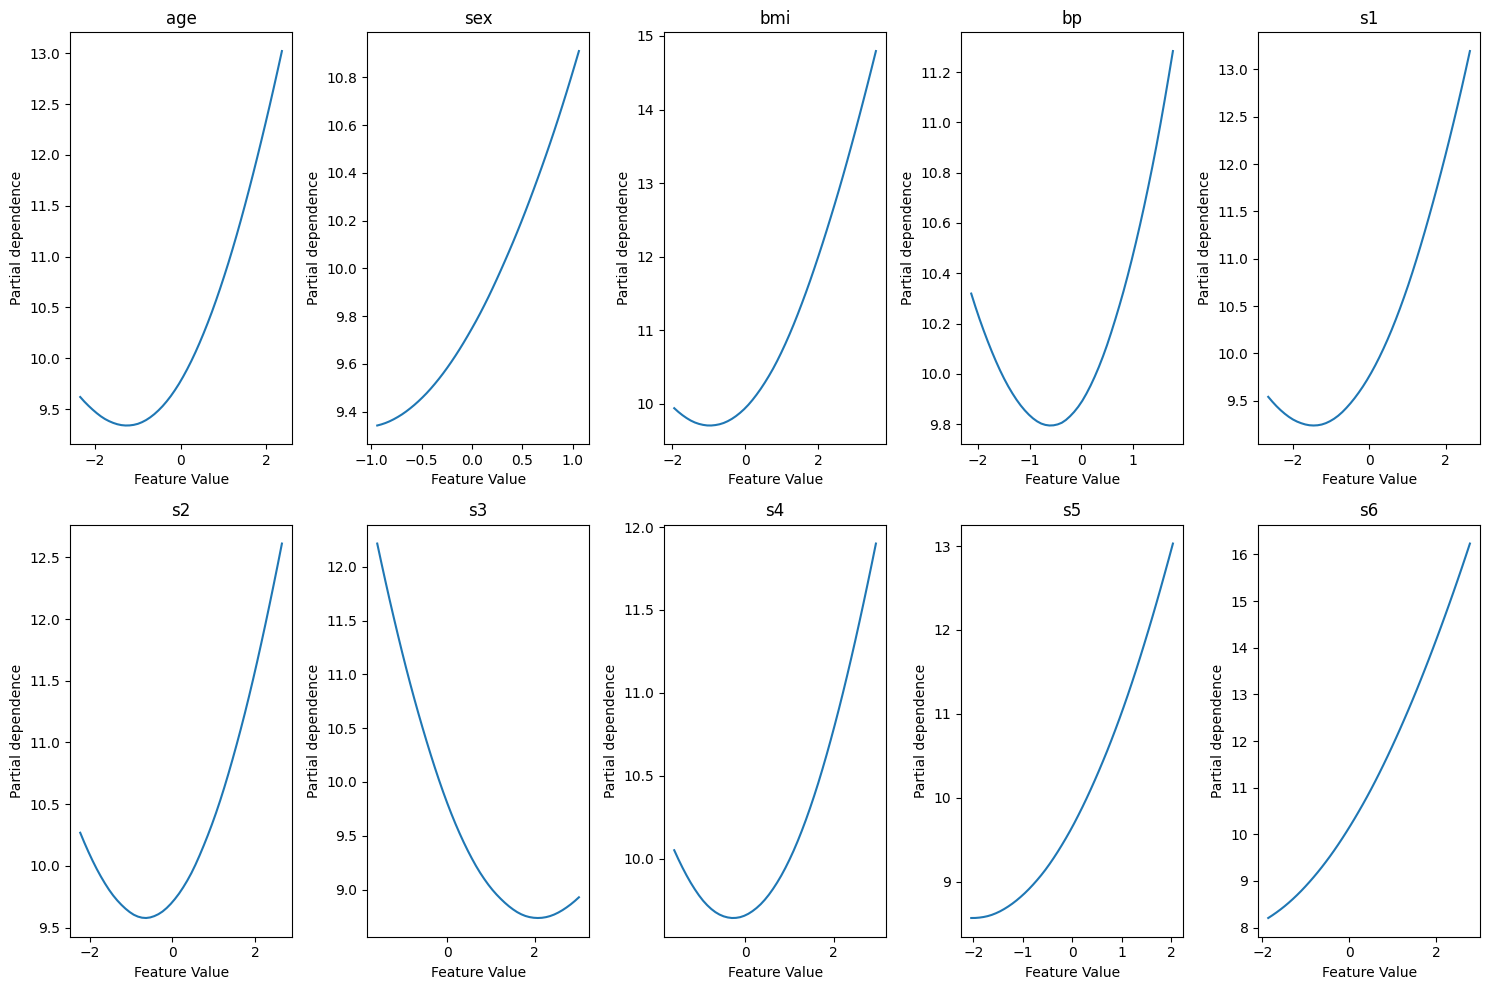

In [1]:
import torch
import torch.nn as nn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import Adam
import pandas as pd

# Carica il dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# Dividi in train e test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizza i dati
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converti in tensori PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

# Definisci il modello
class DiabetesNN(nn.Module):
    def __init__(self):
        super(DiabetesNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.layers(x)

# Inizializza modello, loss e optimizer
model = DiabetesNN()
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)

# Addestra il modello
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Valuta sul test set
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor)
    test_loss = criterion(test_predictions, y_test_tensor)
    print(f'\nTest Loss: {test_loss.item():.4f}')

# Funzione per calcolare PDP per una feature
def calculate_pdp(model, X, feature_idx, grid_points=50):
    feature_min = X[:, feature_idx].min()
    feature_max = X[:, feature_idx].max()
    grid = np.linspace(feature_min, feature_max, grid_points)

    pdp_values = []
    for value in grid:
        X_temp = X.clone()
        X_temp[:, feature_idx] = value
        with torch.no_grad():
            predictions = model(X_temp)
            avg_prediction = predictions.mean().item()
        pdp_values.append(avg_prediction)

    return grid, pdp_values

# Calcola e visualizza PDP per ogni feature
plt.figure(figsize=(15, 10))
for i, feature_name in enumerate(diabetes.feature_names):
    plt.subplot(2, 5, i+1)
    grid, pdp_values = calculate_pdp(model, X_test_tensor, i)
    plt.plot(grid, pdp_values)
    plt.title(feature_name)
    plt.xlabel('Feature Value')
    plt.ylabel('Partial dependence')
plt.tight_layout()
plt.show()

# Pytorch + Wrapper sklearn

Addestramento del modello...
Epoch [10/100], Loss: 29631.4414
Epoch [20/100], Loss: 29521.7402
Epoch [30/100], Loss: 29363.4277
Epoch [40/100], Loss: 29133.5137
Epoch [50/100], Loss: 28807.1211
Epoch [60/100], Loss: 28353.1387
Epoch [70/100], Loss: 27736.9004
Epoch [80/100], Loss: 26923.6875
Epoch [90/100], Loss: 25883.6055
Epoch [100/100], Loss: 24593.4453

Verifica predizioni sul test set:
Test Loss: 21706.9984

Calcolo dei Partial Dependence Plots...


<Figure size 1500x1000 with 0 Axes>

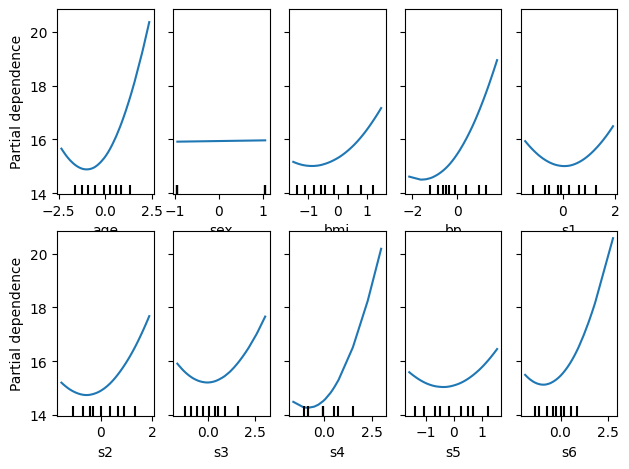

In [10]:
import torch
import torch.nn as nn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_is_fitted
import numpy as np
from torch.optim import Adam
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Carica il dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# Dividi in train e test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizza i dati
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

class SklearnWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, n_epochs=100):
        self.n_epochs = n_epochs

    def _init_model(self):
        self.model_ = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.optimizer_ = Adam(self.model_.parameters(), lr=0.001)
        self.criterion_ = nn.MSELoss()

    def fit(self, X, y):
        self._init_model()

        X_tensor = torch.FloatTensor(X)
        y_tensor = torch.FloatTensor(y).reshape(-1, 1)

        for epoch in range(self.n_epochs):
            self.model_.train()
            self.optimizer_.zero_grad()
            outputs = self.model_(X_tensor)
            loss = self.criterion_(outputs, y_tensor)
            loss.backward()
            self.optimizer_.step()

            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{self.n_epochs}], Loss: {loss.item():.4f}')

        self.is_fitted_ = True
        return self

    def predict(self, X):
        check_is_fitted(self)
        self.model_.eval()
        X_tensor = torch.FloatTensor(X)
        with torch.no_grad():
            return self.model_(X_tensor).numpy().ravel()

# Addestra il modello
print("Addestramento del modello...")
model = SklearnWrapper(n_epochs=100)
model.fit(X_train_scaled, y_train)

# Verifica predizioni
print("\nVerifica predizioni sul test set:")
test_predictions = model.predict(X_test_scaled)
test_loss = np.mean((test_predictions - y_test) ** 2)
print(f'Test Loss: {test_loss:.4f}')

# Crea i PDP
print("\nCalcolo dei Partial Dependence Plots...")
plt.figure(figsize=(15, 10))
display = PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_test_scaled,
    features=range(10),
    feature_names=diabetes.feature_names,
    n_cols=5,
    grid_resolution=50,
    random_state=42
)
plt.tight_layout()
plt.show()

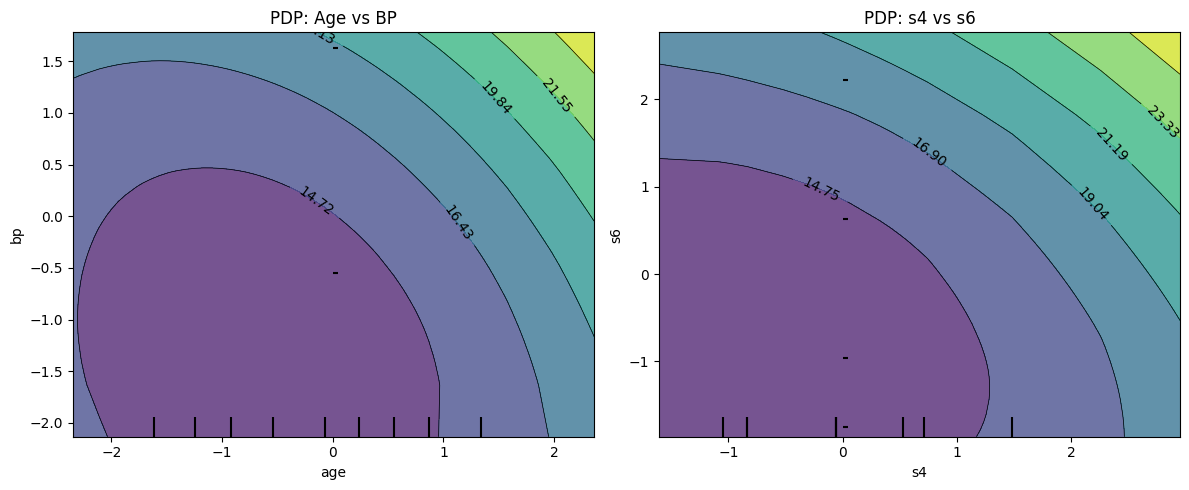

In [13]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Ottieni i nomi delle feature e gli indici
feature_names = diabetes.feature_names
age_idx = feature_names.index('age')
bp_idx = feature_names.index('bp')
s4_idx = feature_names.index('s4')
s6_idx = feature_names.index('s6')

# Crea i PDP bidimensionali
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot PDP per age e bp
display1 = PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_test_scaled,
    features=[(age_idx, bp_idx)],
    feature_names=feature_names,
    kind='average',
    random_state=42,
    ax=[ax1]
)
ax1.set_title('PDP: Age vs BP')

# Plot PDP per s4 e s6
display2 = PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_test_scaled,
    features=[(s4_idx, s6_idx)],
    feature_names=feature_names,
    kind='average',
    random_state=42,
    ax=[ax2]
)
ax2.set_title('PDP: s4 vs s6')

plt.tight_layout()
plt.show()